### PH464/564: Scientific Computing II
___

# Homework 6
### Due: Mon, Dec 1st at 11:59pm Pacific
---

# Identifying M4 cluster members w/ Dense Neural Networks

_NOTE_: I don't include the data here to keep things small. Please get the data from the class repo.

Demonstrate the use of a densely connected neural network, like the one we trained on the MNIST data set, for classifying stars in the M4 cluster using Gaia's measurements of stars' locations on the sky (right ascension and declination). This is basically a repeat of what we covered in class, but this time I want you to even out the training set to include roughly equal numbers of M4 members and non-members.

1. What training and validation accuracies are you able to achieve?

2. Is your trained model confident that any of the stars in your test set are part of M4?

3. What did your model learn? Can you come up with a useful way to probe your model and visualize the results to answer this question?

4. Do you think more sophisticated models could do better with this classification task using only sky positions? Use the properties of the training set to make your argument.

**564 students:**

Make use of other features observed by Gaia to improve your classifier. Be sure to use the data model documentation to understand what each feature is, and explain why you think it would be useful for identifying cluster members. What training and validation accuracies can you achieve? Does your trained model find any stars it believes are confidently in M4 that weren't in the M4 catalog?

In [1]:
import numpy as np

import jax
import jax.numpy as jnp

import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from flax import linen as nn

In [2]:
import matplotlib
matplotlib.rcParams['font.family'] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"
font = {'size' : 14}
plt.rc('font', **font)

In [3]:
m4_df = pd.read_fwf('../data/NGC6121-1.dat', names=['source_id', 'ra', 'dec', 'phot_g_mean_mag'])
m4_df

,source_id,ra,dec,phot_g_mean_mag
0,6045504229661220736,245.99162,-26.34434,18.438
1,6045504981264184192,246.03035,-26.28057,18.769
2,6045508902585952640,245.88761,-26.24297,19.072
3,6045507180287440000,245.85343,-26.28453,18.495
4,6045503473747038464,245.87124,-26.34628,17.163
...,...,...,...,...
19503,6045337962873610240,245.13976,-27.09970,19.705
19504,6045298891556291712,245.48339,-27.19208,19.493
19505,6045305866578950784,245.69445,-27.06942,18.290
19506,6045303774938119808,245.80824,-27.07275,19.267


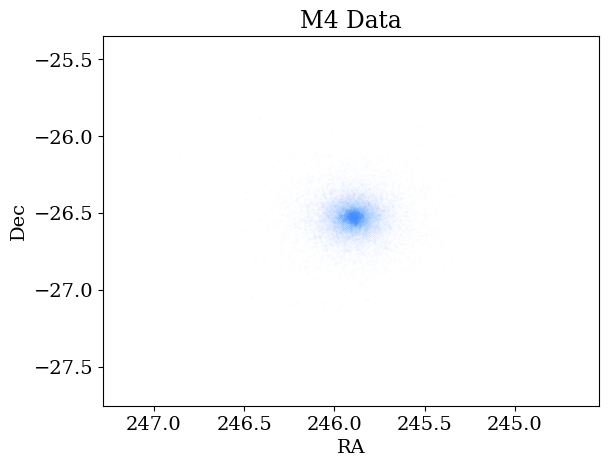

In [4]:
plt.scatter(m4_df.ra, m4_df.dec, s=0.0001, color='dodgerblue')
plt.title('M4 Data')
plt.xlabel('RA')
plt.ylabel('Dec')
plt.gca().invert_xaxis()

In [115]:
df = pd.read_csv('../../hub_data_share/m4_gaia_source.csv')
df.head()

,designation,source_id,ra,dec,parallax,parallax_error,parallax_over_error,pm,pmra,pmra_error,...,phot_g_mean_flux_over_error,phot_g_mean_mag,phot_bp_mean_flux_over_error,phot_bp_mean_mag,phot_rp_mean_flux_over_error,phot_rp_mean_mag,phot_bp_rp_excess_factor,bp_rp,radial_velocity,radial_velocity_error
0,Gaia DR3 6048466004733106048,6048466004733106048,244.500044,-26.152984,2.274643,1.125653,2.020732,8.490148,-7.892926,1.880442,...,110.199646,20.722200,4.511861,21.159956,17.483234,19.606243,1.661088,1.553713,NaN,NaN
1,Gaia DR3 6048666665606296064,6048666665606296064,244.500060,-25.906141,0.632528,0.769472,0.822029,2.582879,-0.097646,0.931963,...,178.075440,20.311983,10.519053,21.239437,20.069353,19.297583,1.380115,1.941855,NaN,NaN
2,Gaia DR3 6048358561832132864,6048358561832132864,244.500066,-26.918531,1.153917,0.907036,1.272184,7.455110,-5.327529,1.236975,...,152.003370,20.567377,7.892730,21.225716,16.701073,19.618095,1.404567,1.607620,NaN,NaN
3,Gaia DR3 6048842759265408128,6048842759265408128,244.500077,-25.216618,NaN,NaN,NaN,NaN,NaN,NaN,...,68.553120,20.875511,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Gaia DR3 6048837635368203648,6048837635368203648,244.500085,-25.318745,0.405547,0.118409,3.424970,1.204035,-0.644142,0.158066,...,959.558700,17.849728,73.395320,18.590256,129.001560,16.973124,1.310396,1.617132,NaN,NaN


In [6]:
df.columns

Index(['designation', 'source_id', 'ra', 'dec', 'parallax', 'parallax_error',
       'parallax_over_error', 'pm', 'pmra', 'pmra_error', 'pmdec',
       'pmdec_error', 'astrometric_n_good_obs_al', 'astrometric_chi2_al',
       'visibility_periods_used', 'phot_g_mean_flux_over_error',
       'phot_g_mean_mag', 'phot_bp_mean_flux_over_error', 'phot_bp_mean_mag',
       'phot_rp_mean_flux_over_error', 'phot_rp_mean_mag',
       'phot_bp_rp_excess_factor', 'bp_rp', 'radial_velocity',
       'radial_velocity_error'],
      dtype='object')

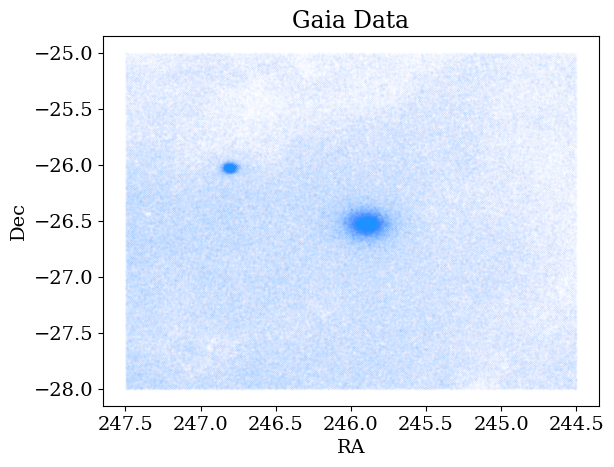

In [7]:
plt.scatter(df.ra, df.dec, s=0.0001, color='dodgerblue')
plt.title('Gaia Data')
plt.xlabel('RA')
plt.ylabel('Dec')
plt.gca().invert_xaxis()

In [8]:
m4_sel = df['source_id'].isin(m4_df.source_id)
print(np.count_nonzero(m4_sel))
print(np.count_nonzero(~m4_sel))

19084
475912


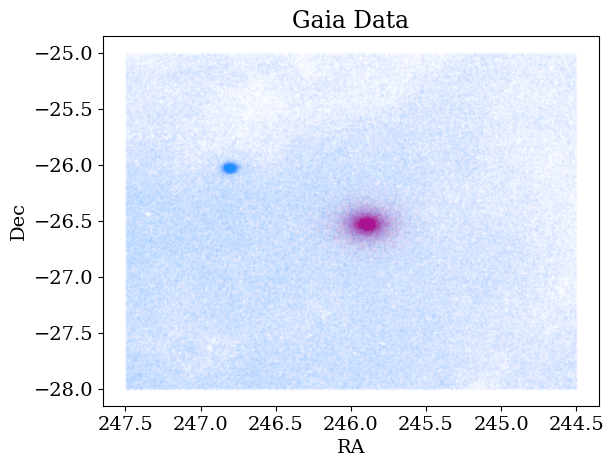

In [9]:
plt.scatter(df.ra[~m4_sel], df.dec[~m4_sel], s=0.0001, color='dodgerblue', label='Non M4 Members')
plt.scatter(df.ra[m4_sel], df.dec[m4_sel], s=0.0001, color='deeppink', label='M4 Members')
plt.title('Gaia Data')
plt.xlabel('RA')
plt.ylabel('Dec')
plt.gca().invert_xaxis()

In [10]:
params = ['ra', 'dec']
X_full = np.array(df[params])
y_full = m4_sel.astype(int)

nans = np.any(np.isnan(X_full), axis=1)
X_full = X_full[~nans]
y_full = y_full[~nans]

m4_mask = y_full == 1
non_mask = y_full == 0

X_m4 = np.array(X_full[m4_mask])
y_m4 = np.array(y_full[m4_mask])
X_non = np.array(X_full[non_mask])
y_non = np.array(y_full[non_mask])

n = X_m4.shape[0]
idx = np.random.choice(X_non.shape[0], size=n, replace=False)

X_non = X_non[idx]
y_non = y_non[idx]

X = np.concatenate((X_m4, X_non))
y = np.concatenate((y_m4, y_non))

print(X.shape, y.shape)

(38168, 2) (38168,)


In [11]:
from sklearn.model_selection import train_test_split

indices = np.arange(X.shape[0])
X_train, X_tst, y_train, y_tst, train_idx, test_idx = train_test_split(X, y, indices, test_size=0.1, shuffle=True, random_state=42)

In [12]:
from sklearn.preprocessing import StandardScaler

In [13]:
transformer = StandardScaler()

X_train = transformer.fit_transform(X_train)
X_tst = transformer.transform(X_tst)

In [14]:
X_train = jnp.array(X_train)
X_tst = jnp.array(X_tst)
y_train = jnp.array(y_train)
y_tst = jnp.array(y_tst)

In [15]:
batch_size = 64
n_batches = X_train.shape[0] // batch_size

X_train = X_train[:n_batches * batch_size].reshape((n_batches, batch_size, *X_train.shape[1:]))
y_train = y_train[:n_batches * batch_size].reshape((n_batches, batch_size, *y_train.shape[1:]))
X_train.shape, y_train.shape

((536, 64, 2), (536, 64))

In [16]:
n_classes = 2

class DenseClassifier(nn.Module):
    """A simple dense classifier."""

    @nn.compact
    def __call__(self, x):
        x = nn.Dense(10)(x)
        x = nn.relu(x)
        x = nn.Dense(10)(x)
        x = nn.relu(x)
        x = nn.Dense(n_classes)(x)
        return x

In [17]:
dummy_input = jnp.ones((1, 2))
dnn = DenseClassifier()
print(dnn.tabulate(jax.random.PRNGKey(0), dummy_input))


                            DenseClassifier Summary                             
┏━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃ path    ┃ module          ┃ inputs        ┃ outputs       ┃ params           ┃
┡━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│         │ DenseClassifier │ float32[1,2]  │ float32[1,2]  │                  │
├─────────┼─────────────────┼───────────────┼───────────────┼──────────────────┤
│ Dense_0 │ Dense           │ float32[1,2]  │ float32[1,10] │ bias:            │
│         │                 │               │               │ float32[10]      │
│         │                 │               │               │ kernel:          │
│         │                 │               │               │ float32[2,10]    │
│         │                 │               │               │                  │
│         │                 │               │               │ 30 (120 B)       │
├─────────┼────────────────

In [18]:
X_train.shape, y_train.shape

((536, 64, 2), (536, 64))

In [19]:
from clu import metrics
from flax.training import train_state
from flax import struct
import optax

In [20]:
@struct.dataclass
class Metrics(metrics.Collection):
    accuracy: metrics.Accuracy
    loss: metrics.Average.from_output('loss')

class TrainState(train_state.TrainState):
   metrics: Metrics

In [21]:
def create_train_state(model, rng, learning_rate):
    params = model.init(rng, dummy_input)['params']
    tx = optax.adam(learning_rate)
    return TrainState.create(
        apply_fn=model.apply, params=params, tx=tx,
        metrics=Metrics.empty())

In [22]:
@jax.jit
def train_step(state, batch, label):
  """Train for a single step."""
  def loss_fn(params):
    logits = state.apply_fn({'params': params}, batch)
    loss = optax.softmax_cross_entropy_with_integer_labels(
        logits=logits, labels=label).mean()
    return loss
  grad_fn = jax.grad(loss_fn)
  grads = grad_fn(state.params)
  state = state.apply_gradients(grads=grads)
  return state

In [23]:
@jax.jit
def compute_metrics(*, state, batch, label):
    logits = state.apply_fn({'params': state.params}, batch)
    loss = optax.softmax_cross_entropy_with_integer_labels(
        logits=logits, labels=label).mean()
    metric_updates = state.metrics.single_from_model_output(
        logits=logits, labels=label, loss=loss)
    metrics = state.metrics.merge(metric_updates)
    state = state.replace(metrics=metrics)
    return state

In [24]:
init_rng = jax.random.PRNGKey(0)

learning_rate = 0.01

state = create_train_state(dnn, init_rng, learning_rate)
del init_rng  # Must not be used anymore.

In [25]:
metrics_history = {'train_loss': [],
                   'train_accuracy': [],
                   'test_loss': [],
                   'test_accuracy': []}

In [26]:
n_epochs = 50

In [27]:
step = 0

for _ in range(n_epochs):
  for batch, label in zip(X_train, y_train):

    # Run optimization steps over training batches and compute batch metrics
    state = train_step(state, batch, label) # get updated train state (which contains the updated parameters)
    state = compute_metrics(state=state, batch=batch, label=label) # aggregate batch metrics

    if (step+1) % n_batches == 0: # one training epoch has passed
      for metric,value in state.metrics.compute().items(): # compute metrics
        metrics_history[f'train_{metric}'].append(value) # record metrics
      state = state.replace(metrics=state.metrics.empty()) # reset train_metrics for next training epoch

      # Compute metrics on the test set after each training epoch
      test_state = state
      test_state = compute_metrics(state=test_state, batch=X_tst, label=y_tst)

      for metric,value in test_state.metrics.compute().items():
        metrics_history[f'test_{metric}'].append(value)

      print(f"train epoch: {(step+1) // n_batches}, "
            f"loss: {metrics_history['train_loss'][-1]}, "
            f"accuracy: {metrics_history['train_accuracy'][-1] * 100}")
      print(f"test epoch: {(step+1) // n_batches}, "
            f"loss: {metrics_history['test_loss'][-1]}, "
            f"accuracy: {metrics_history['test_accuracy'][-1] * 100}")
    step += 1

train epoch: 1, loss: 0.21455088257789612, accuracy: 92.83465576171875
test epoch: 1, loss: 0.21973934769630432, accuracy: 92.716796875
train epoch: 2, loss: 0.2023392766714096, accuracy: 93.07369232177734
test epoch: 2, loss: 0.21761633455753326, accuracy: 92.7691879272461
train epoch: 3, loss: 0.20196403563022614, accuracy: 93.14949035644531
test epoch: 3, loss: 0.21705003082752228, accuracy: 92.82158660888672
train epoch: 4, loss: 0.20172430574893951, accuracy: 93.12616729736328
test epoch: 4, loss: 0.21640489995479584, accuracy: 92.7691879272461
train epoch: 5, loss: 0.20147502422332764, accuracy: 93.1349105834961
test epoch: 5, loss: 0.2163606584072113, accuracy: 92.69058990478516
train epoch: 6, loss: 0.20133134722709656, accuracy: 93.1349105834961
test epoch: 6, loss: 0.21610276401042938, accuracy: 92.74298858642578
train epoch: 7, loss: 0.20131903886795044, accuracy: 93.12908172607422
test epoch: 7, loss: 0.21609176695346832, accuracy: 92.69058990478516
train epoch: 8, loss: 0.

In [28]:
print('Mean training accuracy: %.3f' % np.mean(metrics_history['train_accuracy']))
print('Mean testing accuracy: %.3f' % np.mean(metrics_history['test_accuracy']))

Mean training accuracy: 0.932
Mean testing accuracy: 0.928


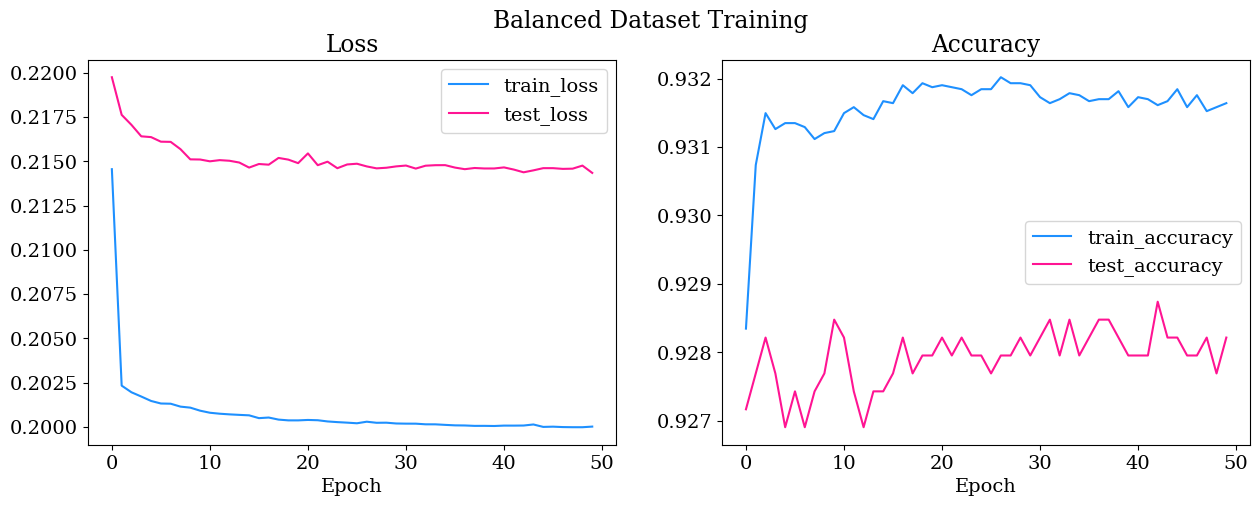

<Figure size 640x480 with 0 Axes>

In [29]:
# Plot loss and accuracy in subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Balanced Dataset Training')
ax1.set_title('Loss')
ax2.set_title('Accuracy')
colors = {
    'train': 'dodgerblue',
    'test': 'deeppink'
}
for dataset in ('train','test'):
  ax1.plot(metrics_history[f'{dataset}_loss'], label=f'{dataset}_loss', color=colors[dataset])
  ax2.plot(metrics_history[f'{dataset}_accuracy'], label=f'{dataset}_accuracy', color=colors[dataset])
ax1.set_xlabel('Epoch')
ax2.set_xlabel('Epoch')
ax1.legend()
ax2.legend()
plt.show()
plt.clf()

In [30]:
@jax.jit
def pred_step(state, batch):
  logits = state.apply_fn({'params': state.params}, batch)
  return logits.argmax(axis=1)

pred = pred_step(state, X_tst)
pred

Array([1, 1, 1, ..., 0, 1, 0], dtype=int32)

(array([1793.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
        2024.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

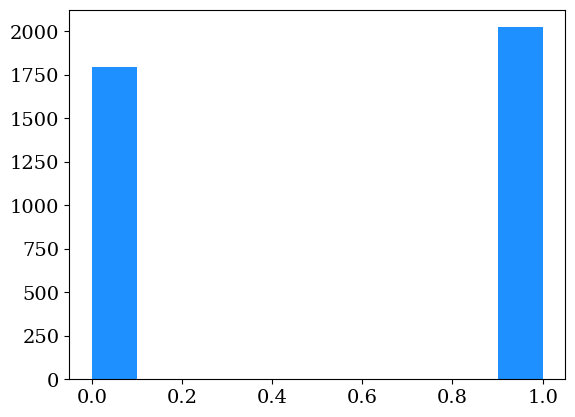

In [31]:
plt.hist(pred, color='dodgerblue')

Text(0.5, 0, 'Logit Difference')

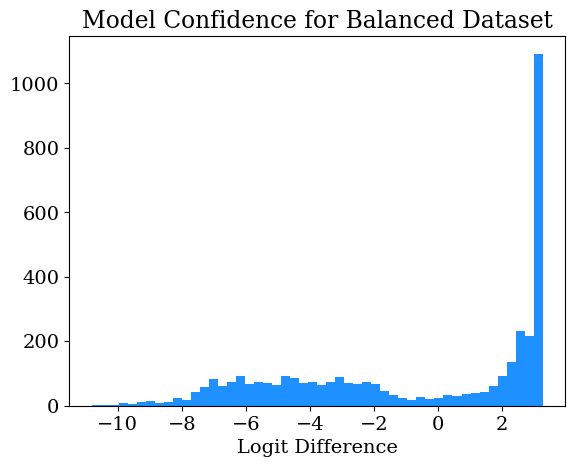

In [36]:
outputs = state.apply_fn({'params': state.params}, X_tst)
plt.hist(jnp.diff(outputs, axis=1).flatten(), color='dodgerblue', bins=50);
plt.title('Model Confidence for Balanced Dataset')
plt.xlabel('Logit Difference')
# plt.xlim(-20,5)

In [33]:
ra_full  = df['ra'][~nans].to_numpy()
dec_full = df['dec'][~nans].to_numpy()

ra_m4 = np.array(ra_full[m4_mask])
ra_non = np.array(ra_full[non_mask])
ra_non = ra_non[idx]

dec_m4 = np.array(dec_full[m4_mask])
dec_non = np.array(dec_full[non_mask])
dec_non = dec_non[idx]

ra = np.concatenate((ra_m4, ra_non))
dec = np.concatenate((dec_m4, dec_non))

print(ra.shape, dec.shape)

(38168,) (38168,)


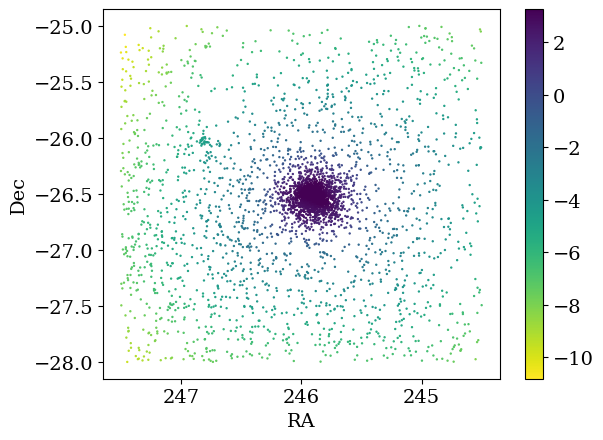

In [34]:
plt.scatter(ra[test_idx], dec[test_idx], c=jnp.diff(outputs, axis=1), s=0.5, cmap='viridis_r')
# plt.title('Balanced Dataset')
plt.xlabel('RA')
plt.ylabel('Dec')
plt.gca().invert_xaxis()
plt.colorbar()

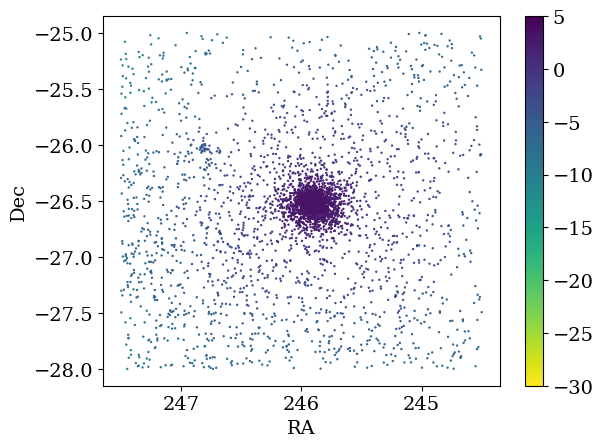

In [35]:
plt.scatter(ra[test_idx], dec[test_idx], c=jnp.diff(outputs, axis=1), s=0.5, cmap='viridis_r', vmin=-30, vmax=5)
# plt.title('Balanced Dataset')
plt.xlabel('RA')
plt.ylabel('Dec')
plt.gca().invert_xaxis()
plt.colorbar()

## 564 Problem

### Including Proper Motion

In [37]:
params = ['ra', 'dec', 'pmra', 'pmdec']
X_full = np.array(df[params])
y_full = m4_sel.astype(int)

nans = np.any(np.isnan(X_full), axis=1)
X_full = X_full[~nans]
y_full = y_full[~nans]

m4_mask = y_full == 1
non_mask = y_full == 0

X_m4 = np.array(X_full[m4_mask])
y_m4 = np.array(y_full[m4_mask])
X_non = np.array(X_full[non_mask])
y_non = np.array(y_full[non_mask])

n = X_m4.shape[0]
idx = np.random.choice(X_non.shape[0], size=n, replace=False)

X_non = X_non[idx]
y_non = y_non[idx]

X = np.concatenate((X_m4, X_non))
y = np.concatenate((y_m4, y_non))

print(X.shape, y.shape)

(38038, 4) (38038,)


In [38]:
indices = np.arange(X.shape[0])
X_train, X_tst, y_train, y_tst, train_idx, test_idx = train_test_split(X, y, indices, test_size=0.1, shuffle=True, random_state=42)

In [39]:
transformer = StandardScaler()

X_train = transformer.fit_transform(X_train)
X_tst = transformer.transform(X_tst)

In [40]:
X_train = jnp.array(X_train)
X_tst = jnp.array(X_tst)
y_train = jnp.array(y_train)
y_tst = jnp.array(y_tst)

In [41]:
batch_size = 64
n_batches = X_train.shape[0] // batch_size

X_train = X_train[:n_batches * batch_size].reshape((n_batches, batch_size, *X_train.shape[1:]))
y_train = y_train[:n_batches * batch_size].reshape((n_batches, batch_size, *y_train.shape[1:]))
X_train.shape, y_train.shape

((534, 64, 4), (534, 64))

In [42]:
n_classes = 2

class DenseClassifier(nn.Module):
    """A simple dense classifier."""

    @nn.compact
    def __call__(self, x):
        x = nn.Dense(10)(x)
        x = nn.relu(x)
        x = nn.Dense(10)(x)
        x = nn.relu(x)
        x = nn.Dense(n_classes)(x)
        return x

In [43]:
dummy_input = jnp.ones((1, 4))
dnn = DenseClassifier()
print(dnn.tabulate(jax.random.PRNGKey(0), dummy_input))


                            DenseClassifier Summary                             
┏━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃ path    ┃ module          ┃ inputs        ┃ outputs       ┃ params           ┃
┡━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│         │ DenseClassifier │ float32[1,4]  │ float32[1,2]  │                  │
├─────────┼─────────────────┼───────────────┼───────────────┼──────────────────┤
│ Dense_0 │ Dense           │ float32[1,4]  │ float32[1,10] │ bias:            │
│         │                 │               │               │ float32[10]      │
│         │                 │               │               │ kernel:          │
│         │                 │               │               │ float32[4,10]    │
│         │                 │               │               │                  │
│         │                 │               │               │ 50 (200 B)       │
├─────────┼────────────────

In [44]:
X_train.shape, y_train.shape

((534, 64, 4), (534, 64))

In [45]:
@struct.dataclass
class Metrics(metrics.Collection):
    accuracy: metrics.Accuracy
    loss: metrics.Average.from_output('loss')

class TrainState(train_state.TrainState):
   metrics: Metrics

In [46]:
def create_train_state(model, rng, learning_rate):
    params = model.init(rng, dummy_input)['params']
    tx = optax.adam(learning_rate)
    return TrainState.create(
        apply_fn=model.apply, params=params, tx=tx,
        metrics=Metrics.empty())

In [47]:
@jax.jit
def train_step(state, batch, label):
  """Train for a single step."""
  def loss_fn(params):
    logits = state.apply_fn({'params': params}, batch)
    loss = optax.softmax_cross_entropy_with_integer_labels(
        logits=logits, labels=label).mean()
    return loss
  grad_fn = jax.grad(loss_fn)
  grads = grad_fn(state.params)
  state = state.apply_gradients(grads=grads)
  return state

In [48]:
@jax.jit
def compute_metrics(*, state, batch, label):
    logits = state.apply_fn({'params': state.params}, batch)
    loss = optax.softmax_cross_entropy_with_integer_labels(
        logits=logits, labels=label).mean()
    metric_updates = state.metrics.single_from_model_output(
        logits=logits, labels=label, loss=loss)
    metrics = state.metrics.merge(metric_updates)
    state = state.replace(metrics=metrics)
    return state

In [49]:
init_rng = jax.random.PRNGKey(0)

learning_rate = 0.01

state = create_train_state(dnn, init_rng, learning_rate)
del init_rng  # Must not be used anymore.

In [50]:
metrics_history = {'train_loss': [],
                   'train_accuracy': [],
                   'test_loss': [],
                   'test_accuracy': []}

In [51]:
n_epochs = 50

In [52]:
step = 0

for _ in range(n_epochs):
  for batch, label in zip(X_train, y_train):

    # Run optimization steps over training batches and compute batch metrics
    state = train_step(state, batch, label) # get updated train state (which contains the updated parameters)
    state = compute_metrics(state=state, batch=batch, label=label) # aggregate batch metrics

    if (step+1) % n_batches == 0: # one training epoch has passed
      for metric,value in state.metrics.compute().items(): # compute metrics
        metrics_history[f'train_{metric}'].append(value) # record metrics
      state = state.replace(metrics=state.metrics.empty()) # reset train_metrics for next training epoch

      # Compute metrics on the test set after each training epoch
      test_state = state
      test_state = compute_metrics(state=test_state, batch=X_tst, label=y_tst)

      for metric,value in test_state.metrics.compute().items():
        metrics_history[f'test_{metric}'].append(value)

      print(f"train epoch: {(step+1) // n_batches}, "
            f"loss: {metrics_history['train_loss'][-1]}, "
            f"accuracy: {metrics_history['train_accuracy'][-1] * 100}")
      print(f"test epoch: {(step+1) // n_batches}, "
            f"loss: {metrics_history['test_loss'][-1]}, "
            f"accuracy: {metrics_history['test_accuracy'][-1] * 100}")
    step += 1

train epoch: 1, loss: 0.07733069360256195, accuracy: 98.21219635009766
test epoch: 1, loss: 0.06055263429880142, accuracy: 98.47528839111328
train epoch: 2, loss: 0.05697694420814514, accuracy: 98.55746459960938
test epoch: 2, loss: 0.05886232852935791, accuracy: 98.50157165527344
train epoch: 3, loss: 0.055659543722867966, accuracy: 98.58965301513672
test epoch: 3, loss: 0.05800558626651764, accuracy: 98.50157165527344
train epoch: 4, loss: 0.0547807551920414, accuracy: 98.6101303100586
test epoch: 4, loss: 0.05816371738910675, accuracy: 98.52787017822266
train epoch: 5, loss: 0.05462644249200821, accuracy: 98.630615234375
test epoch: 5, loss: 0.05734410881996155, accuracy: 98.50157165527344
train epoch: 6, loss: 0.05404694005846977, accuracy: 98.65988159179688
test epoch: 6, loss: 0.05799274891614914, accuracy: 98.50157165527344
train epoch: 7, loss: 0.05339759215712547, accuracy: 98.67158508300781
test epoch: 7, loss: 0.05799553915858269, accuracy: 98.44900512695312
train epoch: 8, 

In [53]:
print('Mean training accuracy: %.3f' % np.mean(metrics_history['train_accuracy']))
print('Mean testing accuracy: %.3f' % np.mean(metrics_history['test_accuracy']))

Mean training accuracy: 0.987
Mean testing accuracy: 0.985


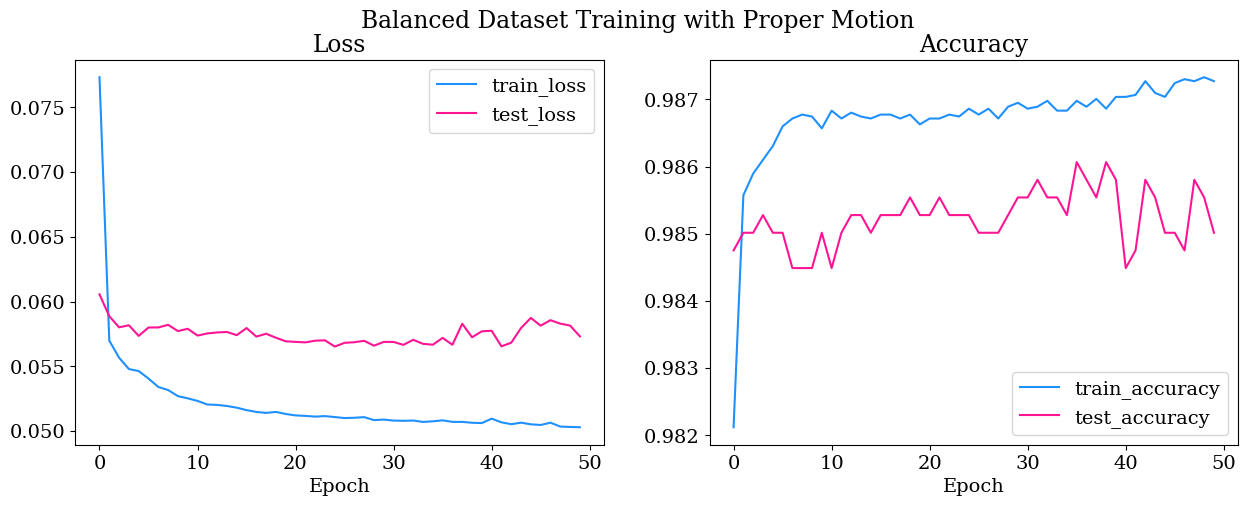

<Figure size 640x480 with 0 Axes>

In [54]:
# Plot loss and accuracy in subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Balanced Dataset Training with Proper Motion')
ax1.set_title('Loss')
ax2.set_title('Accuracy')
colors = {
    'train': 'dodgerblue',
    'test': 'deeppink'
}
for dataset in ('train','test'):
  ax1.plot(metrics_history[f'{dataset}_loss'], label=f'{dataset}_loss', color=colors[dataset])
  ax2.plot(metrics_history[f'{dataset}_accuracy'], label=f'{dataset}_accuracy', color=colors[dataset])
ax1.set_xlabel('Epoch')
ax2.set_xlabel('Epoch')
ax1.legend()
ax2.legend()
plt.show()
plt.clf()

In [55]:
@jax.jit
def pred_step(state, batch):
  logits = state.apply_fn({'params': state.params}, batch)
  return logits.argmax(axis=1)

pred = pred_step(state, X_tst)
pred

Array([0, 1, 0, ..., 1, 1, 0], dtype=int32)

(array([1851.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
        1953.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

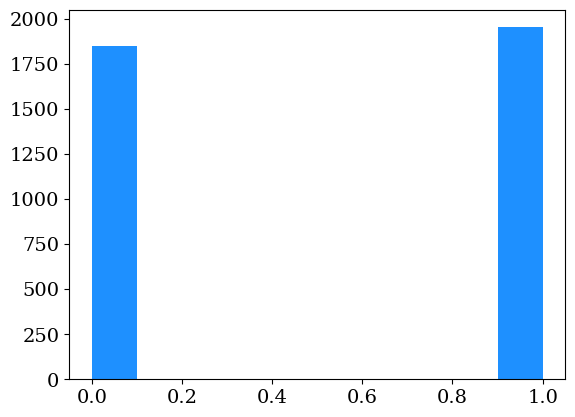

In [56]:
plt.hist(pred, color='dodgerblue')

(-200.0, 10.0)

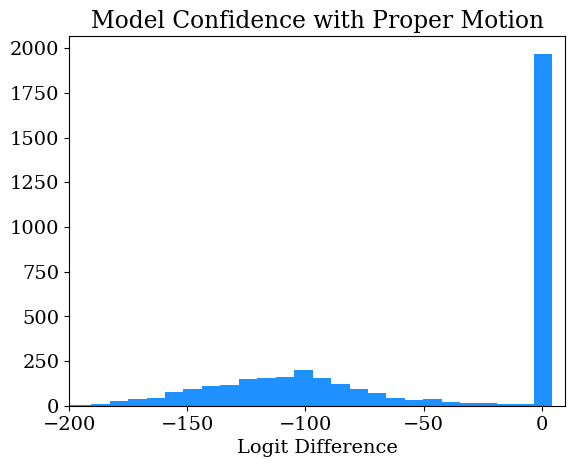

In [61]:
outputs = state.apply_fn({'params': state.params}, X_tst)
plt.hist(jnp.diff(outputs, axis=1).flatten(), color='dodgerblue', bins=50);
plt.title('Model Confidence with Proper Motion')
plt.xlabel('Logit Difference')
plt.xlim(-200,10)

In [58]:
ra_full  = df['ra'][~nans].to_numpy()
dec_full = df['dec'][~nans].to_numpy()

ra_m4 = np.array(ra_full[m4_mask])
ra_non = np.array(ra_full[non_mask])
ra_non = ra_non[idx]

dec_m4 = np.array(dec_full[m4_mask])
dec_non = np.array(dec_full[non_mask])
dec_non = dec_non[idx]

ra = np.concatenate((ra_m4, ra_non))
dec = np.concatenate((dec_m4, dec_non))

print(ra.shape, dec.shape)

(38038,) (38038,)


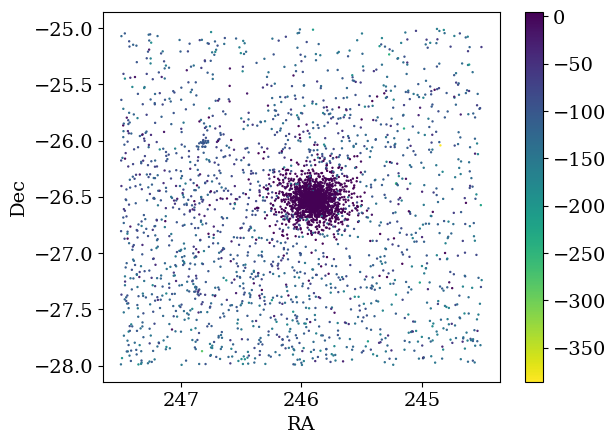

In [59]:
plt.scatter(ra[test_idx], dec[test_idx], c=jnp.diff(outputs, axis=1), s=0.5, cmap='viridis_r')
# plt.title('Balanced Dataset with Proper Motion')
plt.xlabel('RA')
plt.ylabel('Dec')
plt.gca().invert_xaxis()
plt.colorbar()

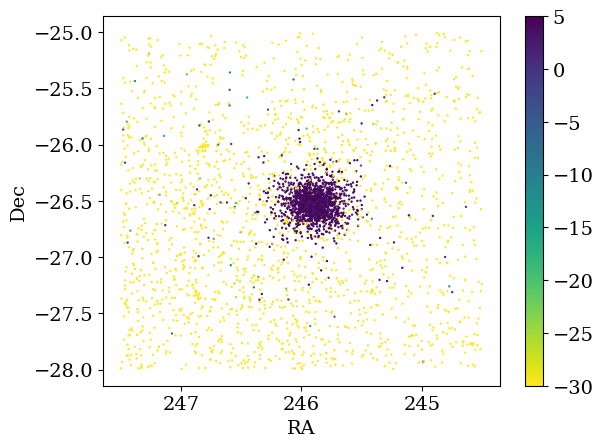

In [60]:
plt.scatter(ra[test_idx], dec[test_idx], c=jnp.diff(outputs, axis=1), s=0.5, cmap='viridis_r', vmin=-30, vmax=5)
# plt.title('Balanced Dataset with Proper Motion')
plt.xlabel('RA')
plt.ylabel('Dec')
plt.gca().invert_xaxis()
plt.colorbar()

### Including Parallax

In [62]:
params = ['ra', 'dec', 'parallax']
X_full = np.array(df[params])
y_full = m4_sel.astype(int)

nans = np.any(np.isnan(X_full), axis=1)
X_full = X_full[~nans]
y_full = y_full[~nans]

m4_mask = y_full == 1
non_mask = y_full == 0

X_m4 = np.array(X_full[m4_mask])
y_m4 = np.array(y_full[m4_mask])
X_non = np.array(X_full[non_mask])
y_non = np.array(y_full[non_mask])

n = X_m4.shape[0]
idx = np.random.choice(X_non.shape[0], size=n, replace=False)

X_non = X_non[idx]
y_non = y_non[idx]

X = np.concatenate((X_m4, X_non))
y = np.concatenate((y_m4, y_non))

print(X.shape, y.shape)

(38038, 3) (38038,)


In [63]:
indices = np.arange(X.shape[0])
X_train, X_tst, y_train, y_tst, train_idx, test_idx = train_test_split(X, y, indices, test_size=0.1, shuffle=True, random_state=42)

In [64]:
transformer = StandardScaler()

X_train = transformer.fit_transform(X_train)
X_tst = transformer.transform(X_tst)

In [65]:
X_train = jnp.array(X_train)
X_tst = jnp.array(X_tst)
y_train = jnp.array(y_train)
y_tst = jnp.array(y_tst)

In [66]:
batch_size = 64
n_batches = X_train.shape[0] // batch_size

X_train = X_train[:n_batches * batch_size].reshape((n_batches, batch_size, *X_train.shape[1:]))
y_train = y_train[:n_batches * batch_size].reshape((n_batches, batch_size, *y_train.shape[1:]))
X_train.shape, y_train.shape

((534, 64, 3), (534, 64))

In [67]:
n_classes = 2

class DenseClassifier(nn.Module):
    """A simple dense classifier."""

    @nn.compact
    def __call__(self, x):
        x = nn.Dense(10)(x)
        x = nn.relu(x)
        x = nn.Dense(10)(x)
        x = nn.relu(x)
        x = nn.Dense(n_classes)(x)
        return x

In [68]:
dummy_input = jnp.ones((1, 3))
dnn = DenseClassifier()
print(dnn.tabulate(jax.random.PRNGKey(0), dummy_input))


                            DenseClassifier Summary                             
┏━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃ path    ┃ module          ┃ inputs        ┃ outputs       ┃ params           ┃
┡━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│         │ DenseClassifier │ float32[1,3]  │ float32[1,2]  │                  │
├─────────┼─────────────────┼───────────────┼───────────────┼──────────────────┤
│ Dense_0 │ Dense           │ float32[1,3]  │ float32[1,10] │ bias:            │
│         │                 │               │               │ float32[10]      │
│         │                 │               │               │ kernel:          │
│         │                 │               │               │ float32[3,10]    │
│         │                 │               │               │                  │
│         │                 │               │               │ 40 (160 B)       │
├─────────┼────────────────

In [69]:
X_train.shape, y_train.shape

((534, 64, 3), (534, 64))

In [70]:
@struct.dataclass
class Metrics(metrics.Collection):
    accuracy: metrics.Accuracy
    loss: metrics.Average.from_output('loss')

class TrainState(train_state.TrainState):
   metrics: Metrics

In [71]:
def create_train_state(model, rng, learning_rate):
    params = model.init(rng, dummy_input)['params']
    tx = optax.adam(learning_rate)
    return TrainState.create(
        apply_fn=model.apply, params=params, tx=tx,
        metrics=Metrics.empty())

In [72]:
@jax.jit
def train_step(state, batch, label):
  """Train for a single step."""
  def loss_fn(params):
    logits = state.apply_fn({'params': params}, batch)
    loss = optax.softmax_cross_entropy_with_integer_labels(
        logits=logits, labels=label).mean()
    return loss
  grad_fn = jax.grad(loss_fn)
  grads = grad_fn(state.params)
  state = state.apply_gradients(grads=grads)
  return state

In [73]:
@jax.jit
def compute_metrics(*, state, batch, label):
    logits = state.apply_fn({'params': state.params}, batch)
    loss = optax.softmax_cross_entropy_with_integer_labels(
        logits=logits, labels=label).mean()
    metric_updates = state.metrics.single_from_model_output(
        logits=logits, labels=label, loss=loss)
    metrics = state.metrics.merge(metric_updates)
    state = state.replace(metrics=metrics)
    return state

In [74]:
init_rng = jax.random.PRNGKey(0)

learning_rate = 0.01

state = create_train_state(dnn, init_rng, learning_rate)
del init_rng  # Must not be used anymore.

In [75]:
metrics_history = {'train_loss': [],
                   'train_accuracy': [],
                   'test_loss': [],
                   'test_accuracy': []}

In [76]:
n_epochs = 50

In [77]:
step = 0

for _ in range(n_epochs):
  for batch, label in zip(X_train, y_train):

    # Run optimization steps over training batches and compute batch metrics
    state = train_step(state, batch, label) # get updated train state (which contains the updated parameters)
    state = compute_metrics(state=state, batch=batch, label=label) # aggregate batch metrics

    if (step+1) % n_batches == 0: # one training epoch has passed
      for metric,value in state.metrics.compute().items(): # compute metrics
        metrics_history[f'train_{metric}'].append(value) # record metrics
      state = state.replace(metrics=state.metrics.empty()) # reset train_metrics for next training epoch

      # Compute metrics on the test set after each training epoch
      test_state = state
      test_state = compute_metrics(state=test_state, batch=X_tst, label=y_tst)

      for metric,value in test_state.metrics.compute().items():
        metrics_history[f'test_{metric}'].append(value)

      print(f"train epoch: {(step+1) // n_batches}, "
            f"loss: {metrics_history['train_loss'][-1]}, "
            f"accuracy: {metrics_history['train_accuracy'][-1] * 100}")
      print(f"test epoch: {(step+1) // n_batches}, "
            f"loss: {metrics_history['test_loss'][-1]}, "
            f"accuracy: {metrics_history['test_accuracy'][-1] * 100}")
    step += 1

train epoch: 1, loss: 0.17633458971977234, accuracy: 94.13038635253906
test epoch: 1, loss: 0.16978436708450317, accuracy: 94.19032287597656
train epoch: 2, loss: 0.15129822492599487, accuracy: 94.80921936035156
test epoch: 2, loss: 0.16752316057682037, accuracy: 94.34805297851562
train epoch: 3, loss: 0.14912274479866028, accuracy: 94.8999252319336
test epoch: 3, loss: 0.1648835390806198, accuracy: 94.4794921875
train epoch: 4, loss: 0.14804482460021973, accuracy: 94.92333221435547
test epoch: 4, loss: 0.16240768134593964, accuracy: 94.76866912841797
train epoch: 5, loss: 0.1474798321723938, accuracy: 94.95259857177734
test epoch: 5, loss: 0.16216816008090973, accuracy: 94.9263916015625
train epoch: 6, loss: 0.1472896784543991, accuracy: 94.95845031738281
test epoch: 6, loss: 0.16305376589298248, accuracy: 94.74237823486328
train epoch: 7, loss: 0.14715203642845154, accuracy: 94.98477935791016
test epoch: 7, loss: 0.16294878721237183, accuracy: 94.79495239257812
train epoch: 8, loss: 

In [78]:
print('Mean training accuracy: %.3f' % np.mean(metrics_history['train_accuracy']))
print('Mean testing accuracy: %.3f' % np.mean(metrics_history['test_accuracy']))

Mean training accuracy: 0.950
Mean testing accuracy: 0.946


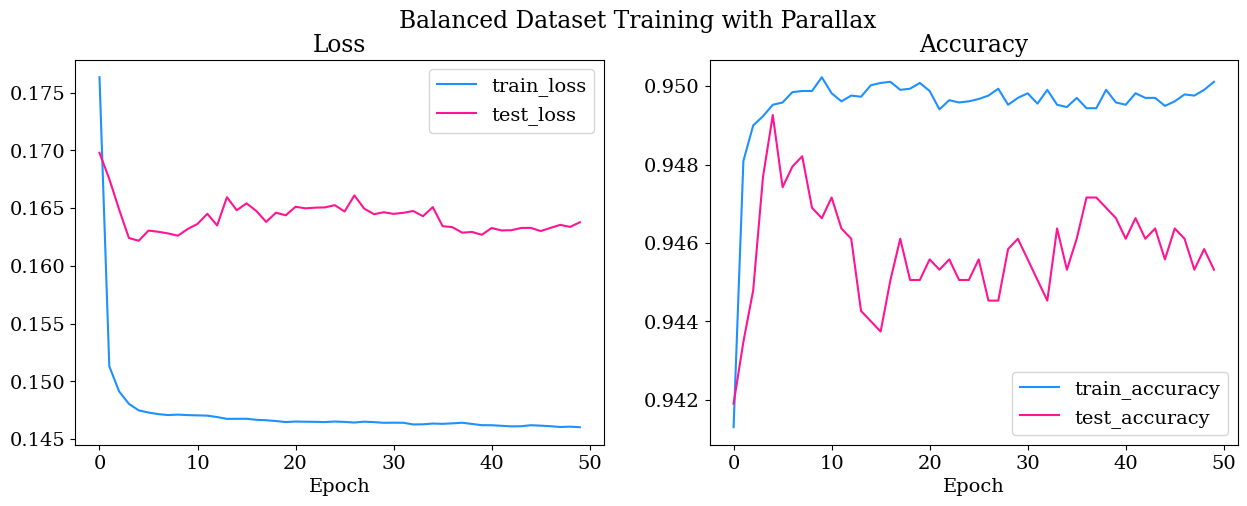

<Figure size 640x480 with 0 Axes>

In [79]:
# Plot loss and accuracy in subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Balanced Dataset Training with Parallax')
ax1.set_title('Loss')
ax2.set_title('Accuracy')
colors = {
    'train': 'dodgerblue',
    'test': 'deeppink'
}
for dataset in ('train','test'):
  ax1.plot(metrics_history[f'{dataset}_loss'], label=f'{dataset}_loss', color=colors[dataset])
  ax2.plot(metrics_history[f'{dataset}_accuracy'], label=f'{dataset}_accuracy', color=colors[dataset])
ax1.set_xlabel('Epoch')
ax2.set_xlabel('Epoch')
ax1.legend()
ax2.legend()
plt.show()
plt.clf()

In [80]:
@jax.jit
def pred_step(state, batch):
  logits = state.apply_fn({'params': state.params}, batch)
  return logits.argmax(axis=1)

pred = pred_step(state, X_tst)
pred

Array([0, 1, 0, ..., 1, 1, 0], dtype=int32)

(array([1824.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
        1980.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

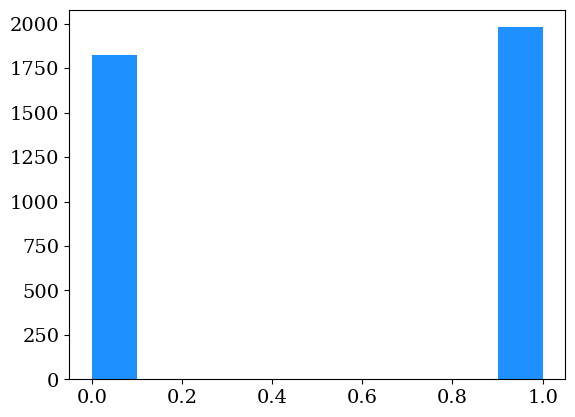

In [81]:
plt.hist(pred, color='dodgerblue')

(-15.0, 5.0)

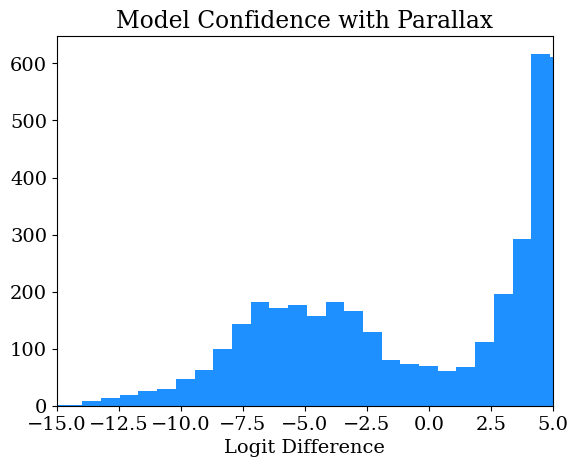

In [87]:
outputs = state.apply_fn({'params': state.params}, X_tst)
plt.hist(jnp.diff(outputs, axis=1).flatten(), color='dodgerblue', bins=50);
plt.title('Model Confidence with Parallax')
plt.xlabel('Logit Difference')
plt.xlim(-15,5)

In [83]:
ra_full  = df['ra'][~nans].to_numpy()
dec_full = df['dec'][~nans].to_numpy()

ra_m4 = np.array(ra_full[m4_mask])
ra_non = np.array(ra_full[non_mask])
ra_non = ra_non[idx]

dec_m4 = np.array(dec_full[m4_mask])
dec_non = np.array(dec_full[non_mask])
dec_non = dec_non[idx]

ra = np.concatenate((ra_m4, ra_non))
dec = np.concatenate((dec_m4, dec_non))

print(ra.shape, dec.shape)

(38038,) (38038,)


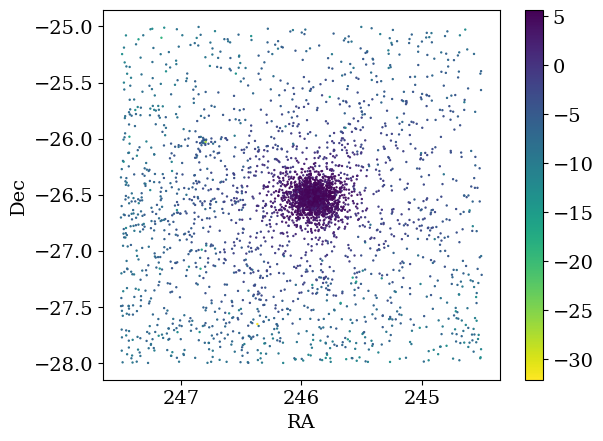

In [84]:
plt.scatter(ra[test_idx], dec[test_idx], c=jnp.diff(outputs, axis=1), s=0.5, cmap='viridis_r')
# plt.title('Balanced Dataset with Parallax')
plt.xlabel('RA')
plt.ylabel('Dec')
plt.gca().invert_xaxis()
plt.colorbar()

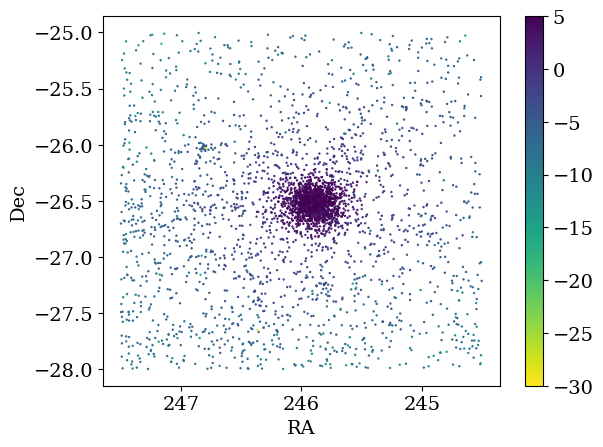

In [85]:
plt.scatter(ra[test_idx], dec[test_idx], c=jnp.diff(outputs, axis=1), s=0.5, cmap='viridis_r', vmin=-30, vmax=5)
# plt.title('Balanced Dataset with Parallax')
plt.xlabel('RA')
plt.ylabel('Dec')
plt.gca().invert_xaxis()
plt.colorbar()

### Including Both

In [88]:
params = ['ra', 'dec', 'parallax', 'pmra', 'pmdec']
X_full = np.array(df[params])
y_full = m4_sel.astype(int)

nans = np.any(np.isnan(X_full), axis=1)
X_full = X_full[~nans]
y_full = y_full[~nans]

m4_mask = y_full == 1
non_mask = y_full == 0

X_m4 = np.array(X_full[m4_mask])
y_m4 = np.array(y_full[m4_mask])
X_non = np.array(X_full[non_mask])
y_non = np.array(y_full[non_mask])

n = X_m4.shape[0]
idx = np.random.choice(X_non.shape[0], size=n, replace=False)

X_non = X_non[idx]
y_non = y_non[idx]

X = np.concatenate((X_m4, X_non))
y = np.concatenate((y_m4, y_non))

print(X.shape, y.shape)

(38038, 5) (38038,)


In [89]:
indices = np.arange(X.shape[0])
X_train, X_tst, y_train, y_tst, train_idx, test_idx = train_test_split(X, y, indices, test_size=0.1, shuffle=True, random_state=42)

In [90]:
transformer = StandardScaler()

X_train = transformer.fit_transform(X_train)
X_tst = transformer.transform(X_tst)

In [91]:
X_train = jnp.array(X_train)
X_tst = jnp.array(X_tst)
y_train = jnp.array(y_train)
y_tst = jnp.array(y_tst)

In [92]:
batch_size = 64
n_batches = X_train.shape[0] // batch_size

X_train = X_train[:n_batches * batch_size].reshape((n_batches, batch_size, *X_train.shape[1:]))
y_train = y_train[:n_batches * batch_size].reshape((n_batches, batch_size, *y_train.shape[1:]))
X_train.shape, y_train.shape

((534, 64, 5), (534, 64))

In [93]:
n_classes = 2

class DenseClassifier(nn.Module):
    """A simple dense classifier."""

    @nn.compact
    def __call__(self, x):
        x = nn.Dense(10)(x)
        x = nn.relu(x)
        x = nn.Dense(10)(x)
        x = nn.relu(x)
        x = nn.Dense(n_classes)(x)
        return x

In [94]:
dummy_input = jnp.ones((1, 5))
dnn = DenseClassifier()
print(dnn.tabulate(jax.random.PRNGKey(0), dummy_input))


                            DenseClassifier Summary                             
┏━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃ path    ┃ module          ┃ inputs        ┃ outputs       ┃ params           ┃
┡━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│         │ DenseClassifier │ float32[1,5]  │ float32[1,2]  │                  │
├─────────┼─────────────────┼───────────────┼───────────────┼──────────────────┤
│ Dense_0 │ Dense           │ float32[1,5]  │ float32[1,10] │ bias:            │
│         │                 │               │               │ float32[10]      │
│         │                 │               │               │ kernel:          │
│         │                 │               │               │ float32[5,10]    │
│         │                 │               │               │                  │
│         │                 │               │               │ 60 (240 B)       │
├─────────┼────────────────

In [95]:
X_train.shape, y_train.shape

((534, 64, 5), (534, 64))

In [96]:
@struct.dataclass
class Metrics(metrics.Collection):
    accuracy: metrics.Accuracy
    loss: metrics.Average.from_output('loss')

class TrainState(train_state.TrainState):
   metrics: Metrics

In [97]:
def create_train_state(model, rng, learning_rate):
    params = model.init(rng, dummy_input)['params']
    tx = optax.adam(learning_rate)
    return TrainState.create(
        apply_fn=model.apply, params=params, tx=tx,
        metrics=Metrics.empty())

In [98]:
@jax.jit
def train_step(state, batch, label):
  """Train for a single step."""
  def loss_fn(params):
    logits = state.apply_fn({'params': params}, batch)
    loss = optax.softmax_cross_entropy_with_integer_labels(
        logits=logits, labels=label).mean()
    return loss
  grad_fn = jax.grad(loss_fn)
  grads = grad_fn(state.params)
  state = state.apply_gradients(grads=grads)
  return state

In [99]:
@jax.jit
def compute_metrics(*, state, batch, label):
    logits = state.apply_fn({'params': state.params}, batch)
    loss = optax.softmax_cross_entropy_with_integer_labels(
        logits=logits, labels=label).mean()
    metric_updates = state.metrics.single_from_model_output(
        logits=logits, labels=label, loss=loss)
    metrics = state.metrics.merge(metric_updates)
    state = state.replace(metrics=metrics)
    return state

In [100]:
init_rng = jax.random.PRNGKey(0)

learning_rate = 0.01

state = create_train_state(dnn, init_rng, learning_rate)
del init_rng  # Must not be used anymore.

In [101]:
metrics_history = {'train_loss': [],
                   'train_accuracy': [],
                   'test_loss': [],
                   'test_accuracy': []}

In [102]:
n_epochs = 50

In [103]:
step = 0

for _ in range(n_epochs):
  for batch, label in zip(X_train, y_train):

    # Run optimization steps over training batches and compute batch metrics
    state = train_step(state, batch, label) # get updated train state (which contains the updated parameters)
    state = compute_metrics(state=state, batch=batch, label=label) # aggregate batch metrics

    if (step+1) % n_batches == 0: # one training epoch has passed
      for metric,value in state.metrics.compute().items(): # compute metrics
        metrics_history[f'train_{metric}'].append(value) # record metrics
      state = state.replace(metrics=state.metrics.empty()) # reset train_metrics for next training epoch

      # Compute metrics on the test set after each training epoch
      test_state = state
      test_state = compute_metrics(state=test_state, batch=X_tst, label=y_tst)

      for metric,value in test_state.metrics.compute().items():
        metrics_history[f'test_{metric}'].append(value)

      print(f"train epoch: {(step+1) // n_batches}, "
            f"loss: {metrics_history['train_loss'][-1]}, "
            f"accuracy: {metrics_history['train_accuracy'][-1] * 100}")
      print(f"test epoch: {(step+1) // n_batches}, "
            f"loss: {metrics_history['test_loss'][-1]}, "
            f"accuracy: {metrics_history['test_accuracy'][-1] * 100}")
    step += 1

train epoch: 1, loss: 0.06441208720207214, accuracy: 98.42286682128906
test epoch: 1, loss: 0.043687403202056885, accuracy: 98.97476196289062
train epoch: 2, loss: 0.04555429145693779, accuracy: 98.76229095458984
test epoch: 2, loss: 0.04008696600794792, accuracy: 98.97476196289062
train epoch: 3, loss: 0.04301077872514725, accuracy: 98.8500747680664
test epoch: 3, loss: 0.03722047433257103, accuracy: 99.02734375
train epoch: 4, loss: 0.04162770137190819, accuracy: 98.9056625366211
test epoch: 4, loss: 0.03713224455714226, accuracy: 99.05362701416016
train epoch: 5, loss: 0.04121016710996628, accuracy: 98.9056625366211
test epoch: 5, loss: 0.03591368347406387, accuracy: 99.05362701416016
train epoch: 6, loss: 0.04072831943631172, accuracy: 98.89981079101562
test epoch: 6, loss: 0.03513920307159424, accuracy: 99.02734375
train epoch: 7, loss: 0.04049534350633621, accuracy: 98.9085922241211
test epoch: 7, loss: 0.0343305803835392, accuracy: 99.00105285644531
train epoch: 8, loss: 0.04044

In [104]:
print('Mean training accuracy: %.3f' % np.mean(metrics_history['train_accuracy']))
print('Mean testing accuracy: %.3f' % np.mean(metrics_history['test_accuracy']))

Mean training accuracy: 0.989
Mean testing accuracy: 0.991


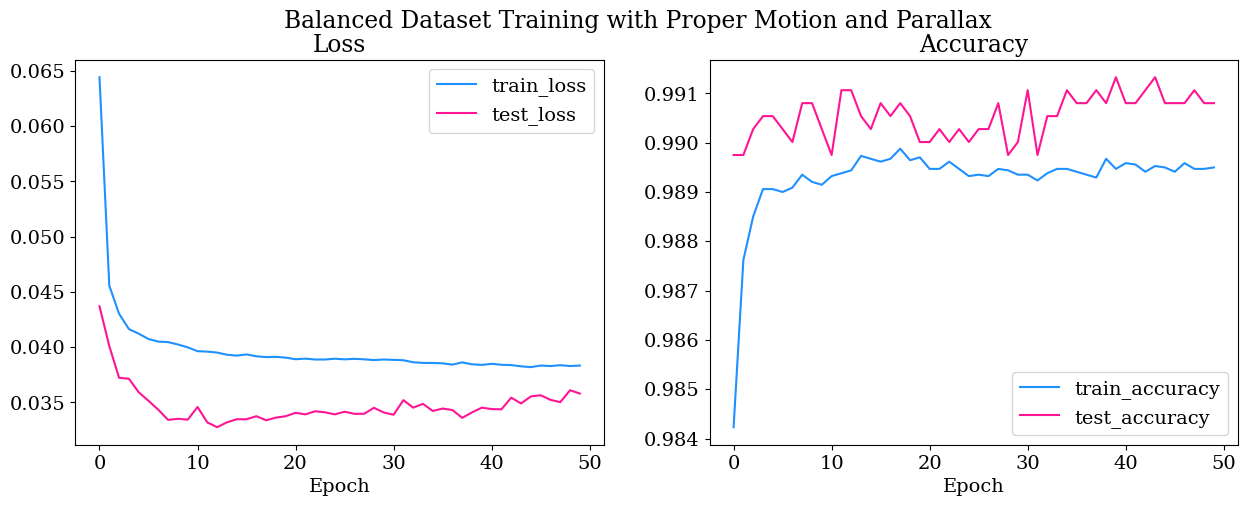

<Figure size 640x480 with 0 Axes>

In [105]:
# Plot loss and accuracy in subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Balanced Dataset Training with Proper Motion and Parallax')
ax1.set_title('Loss')
ax2.set_title('Accuracy')
colors = {
    'train': 'dodgerblue',
    'test': 'deeppink'
}
for dataset in ('train','test'):
  ax1.plot(metrics_history[f'{dataset}_loss'], label=f'{dataset}_loss', color=colors[dataset])
  ax2.plot(metrics_history[f'{dataset}_accuracy'], label=f'{dataset}_accuracy', color=colors[dataset])
ax1.set_xlabel('Epoch')
ax2.set_xlabel('Epoch')
ax1.legend()
ax2.legend()
plt.show()
plt.clf()

In [106]:
@jax.jit
def pred_step(state, batch):
  logits = state.apply_fn({'params': state.params}, batch)
  return logits.argmax(axis=1)

pred = pred_step(state, X_tst)
pred

Array([0, 1, 0, ..., 1, 1, 0], dtype=int32)

(array([1875.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
        1929.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

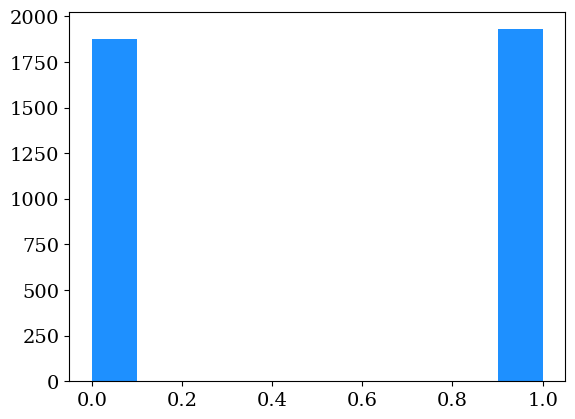

In [107]:
plt.hist(pred, color='dodgerblue')

(-100.0, 10.0)

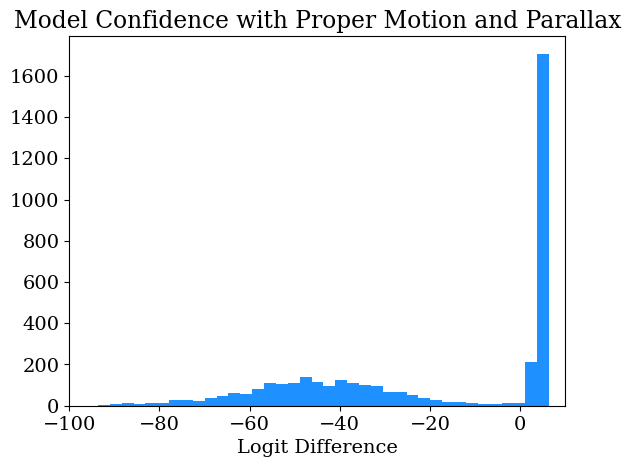

In [113]:
outputs = state.apply_fn({'params': state.params}, X_tst)
plt.hist(jnp.diff(outputs, axis=1).flatten(), color='dodgerblue', bins=50);
plt.title('Model Confidence with Proper Motion and Parallax')
plt.xlabel('Logit Difference')
plt.xlim(-100, 10)

In [109]:
ra_full  = df['ra'][~nans].to_numpy()
dec_full = df['dec'][~nans].to_numpy()

ra_m4 = np.array(ra_full[m4_mask])
ra_non = np.array(ra_full[non_mask])
ra_non = ra_non[idx]

dec_m4 = np.array(dec_full[m4_mask])
dec_non = np.array(dec_full[non_mask])
dec_non = dec_non[idx]

ra = np.concatenate((ra_m4, ra_non))
dec = np.concatenate((dec_m4, dec_non))

print(ra.shape, dec.shape)

(38038,) (38038,)


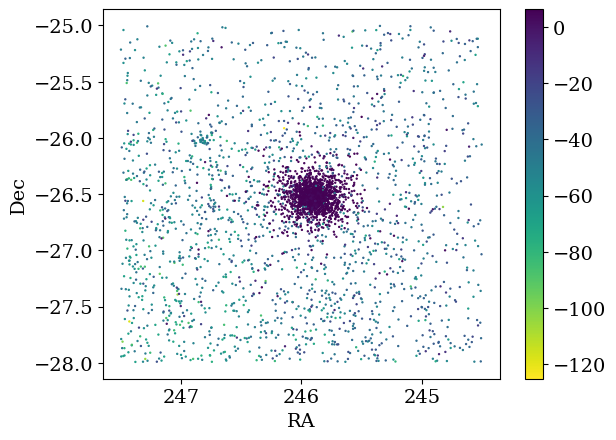

In [110]:
plt.scatter(ra[test_idx], dec[test_idx], c=jnp.diff(outputs, axis=1), s=0.5, cmap='viridis_r')
# plt.title('Balanced Dataset with Proper Motion and Parallax')
plt.xlabel('RA')
plt.ylabel('Dec')
plt.gca().invert_xaxis()
plt.colorbar()

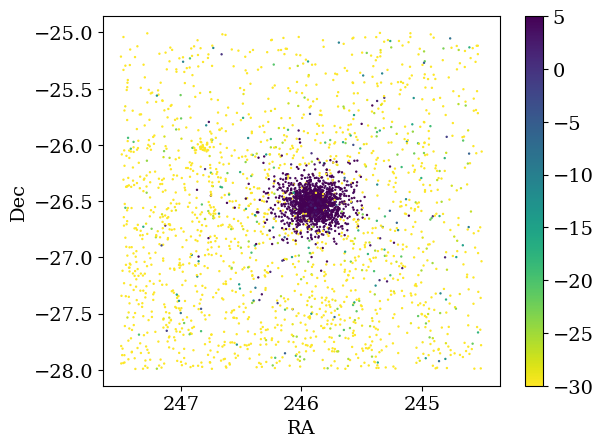

In [111]:
plt.scatter(ra[test_idx], dec[test_idx], c=jnp.diff(outputs, axis=1), s=0.5, cmap='viridis_r', vmin=-30, vmax=5)
# plt.title('Balanced Dataset with Proper Motion and Parallax')
plt.xlabel('RA')
plt.ylabel('Dec')
plt.gca().invert_xaxis()
plt.colorbar()